<a href="https://colab.research.google.com/github/bisht111/celebal_t_assignment/blob/main/week5_divyanshu_bisht.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


#  Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



#  Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)


input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Vocabulary Size: 37
X Shape: (35, 7)
y Shape: (35,)


 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

def build_rnn():

    model = Sequential([
        Embedding(total_words, 64, input_length=max_len-1),
        SimpleRNN(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
rnn_model = build_rnn()

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=150,
    verbose=1
)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.0286 - loss: 3.6199
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1429 - loss: 3.5411
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4000 - loss: 3.4876 
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4000 - loss: 3.4391 
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4286 - loss: 3.3914 
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4000 - loss: 3.3384 
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4000 - loss: 3.2838
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4000 - loss: 3.2254
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4000 - loss: 3.1641
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4286 - loss: 3.0999
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4857 - loss: 3.0437
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4857 - loss: 2.97

#  Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

def build_lstm():

    model = Sequential([
        Embedding(total_words, 64, input_length=max_len-1),
        LSTM(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [8]:
print("\nTraining LSTM...\n")

lstm_model = build_lstm()

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=150,
    verbose=1
)

print("\nLSTM Training Complete\n")


Training LSTM...

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.0000e+00 - loss: 3.6116
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1143 - loss: 3.6033
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1143 - loss: 3.5975
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1714 - loss: 3.5912
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1429 - loss: 3.5849
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1429 - loss: 3.5781
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0857 - loss: 3.5701
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0857 - loss: 3.5617
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0857 - loss: 3.5511
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0857 - loss: 3.5395
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0571 - loss: 3.5232
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step 

# Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

def build_gru():

    model = Sequential([
        Embedding(total_words, 64, input_length=max_len-1),
        GRU(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [10]:
print("\nTraining GRU...\n")

gru_model = build_gru()

gru_history = gru_model.fit(
    X,
    y,
    epochs=150,
    verbose=1
)

print("\nGRU Training Complete\n")


Training GRU...

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0000e+00 - loss: 3.6148
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0000e+00 - loss: 3.6019 
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1429 - loss: 3.5926
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1429 - loss: 3.5834
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1429 - loss: 3.5743
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1714 - loss: 3.5653
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1714 - loss: 3.5547
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1714 - loss: 3.5447
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1143 - loss: 3.5327
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0857 - loss: 3.5205
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0857 - loss: 3.5062
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/s

#Compare Training Loss

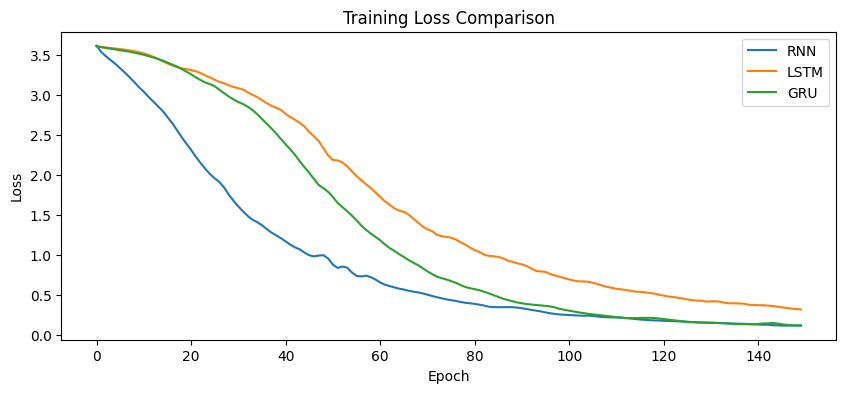

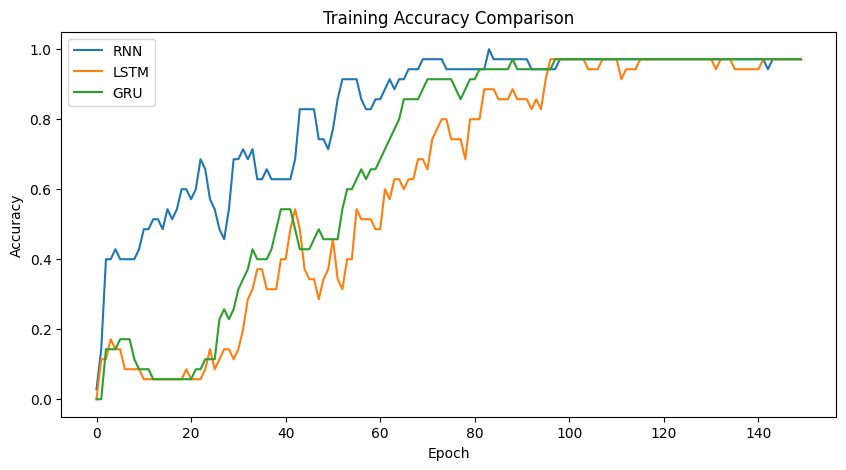

In [11]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [12]:
def generate_text(model, seed_text, next_words=8):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

**Generate Text Samples**

In [13]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is transforming artificial intelligence sentences
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**